# Image compression with K-Means 🖼️

A standard RGB image uses 3 bytes per pixel, which lets it represent up to $256^3 \approx 16.7$ million colors. In practice, most images only rely on a much smaller palette.

👉 In this challenge, we will use **K-Means** to find the `K` most representative colors of an image, and replace every pixel by the closest one. The result is a compressed image using only `K` colors.

## 0) Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

np.random.seed(42)

## 1) Load an image

❓ Load a sample image from scikit-learn (`china.jpg`) and display it.

Image shape: (427, 640, 3)
Dtype: uint8


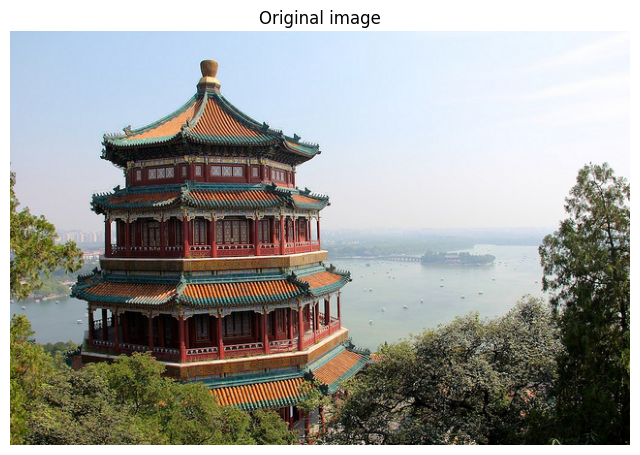

In [2]:
from sklearn.datasets import load_sample_image

image = load_sample_image("china.jpg")
print("Image shape:", image.shape)
print("Dtype:", image.dtype)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis('off')
plt.title("Original image")
plt.show()

☝️ The image is a 3D array `(height, width, 3)` with integer RGB values in `[0, 255]`.

❓ How many **distinct colors** does the original image contain?

In [3]:
h, w, c = image.shape
pixels = image.reshape(-1, 3)
n_unique = len(np.unique(pixels, axis=0))
print(f"Original image contains {n_unique:,} distinct colors")

Original image contains 96,615 distinct colors


## 2) Reshape the image into a dataset of pixels

To feed K-Means, we must think of each pixel as an independent observation in a 3D (RGB) space. We also rescale pixel values to `[0, 1]` floats (nicer for distance computations).

In [4]:
X = image.reshape(-1, 3) / 255.0
print("X shape:", X.shape)
print("X min / max:", X.min(), X.max())

X shape: (273280, 3)
X min / max: 0.0 1.0


## 3) Fit K-Means to build the new color palette

❓ Fit `KMeans` with `K=16` clusters on the pixels. Each cluster centroid will be one of the 16 colors of our reduced palette.

💡 Running K-Means on ~300K pixels can be slow. We'll fit on a random subsample, then predict labels for all pixels.

In [5]:
K = 16

sample_idx = np.random.choice(X.shape[0], size=10_000, replace=False)
X_sample = X[sample_idx]

kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
kmeans.fit(X_sample)

palette = kmeans.cluster_centers_
labels = kmeans.predict(X)

print("Palette shape:", palette.shape)
print("Labels shape:", labels.shape)

Palette shape: (16, 3)
Labels shape: (273280,)


❓ Visualize the learned color palette.

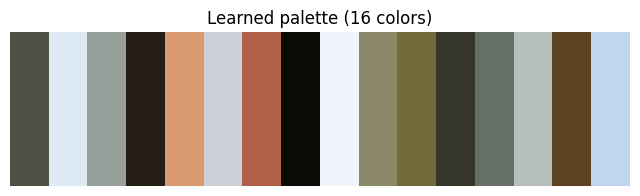

In [6]:
plt.figure(figsize=(8, 2))
plt.imshow(palette[np.newaxis, :, :], aspect='auto')
plt.axis('off')
plt.title(f"Learned palette ({K} colors)")
plt.show()

## 4) Rebuild the compressed image

❓ Replace every pixel by the centroid of its cluster, then reshape back to an `(h, w, 3)` image.

In [7]:
compressed_pixels = palette[labels]
compressed_image = compressed_pixels.reshape(h, w, 3)

print("Compressed image shape:", compressed_image.shape)
print("Distinct colors now:", len(np.unique(compressed_pixels, axis=0)))

Compressed image shape: (427, 640, 3)


Distinct colors now: 16


## 5) Compare original vs compressed

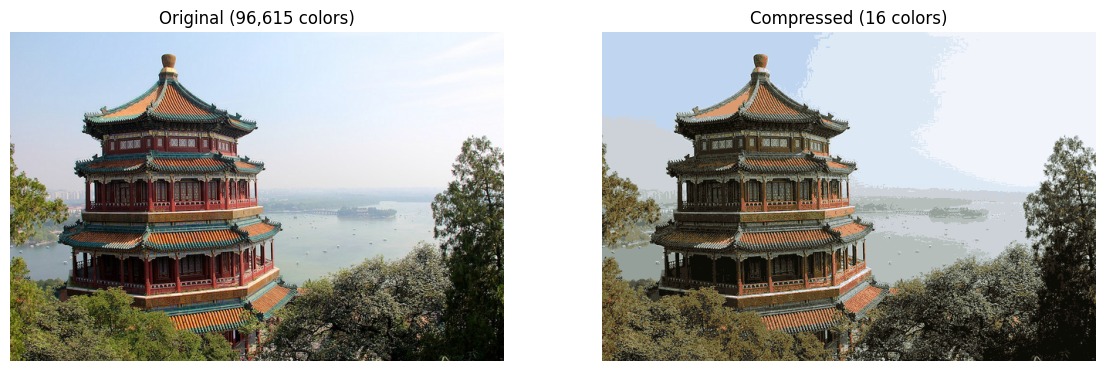

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(image)
axes[0].set_title(f"Original ({n_unique:,} colors)")
axes[0].axis('off')

axes[1].imshow(compressed_image)
axes[1].set_title(f"Compressed ({K} colors)")
axes[1].axis('off')

plt.show()

## 6) Explore the effect of K

❓ Write a function that returns the compressed image for any value of `K`, then display the result for `K ∈ {2, 4, 8, 16, 32, 64}`.

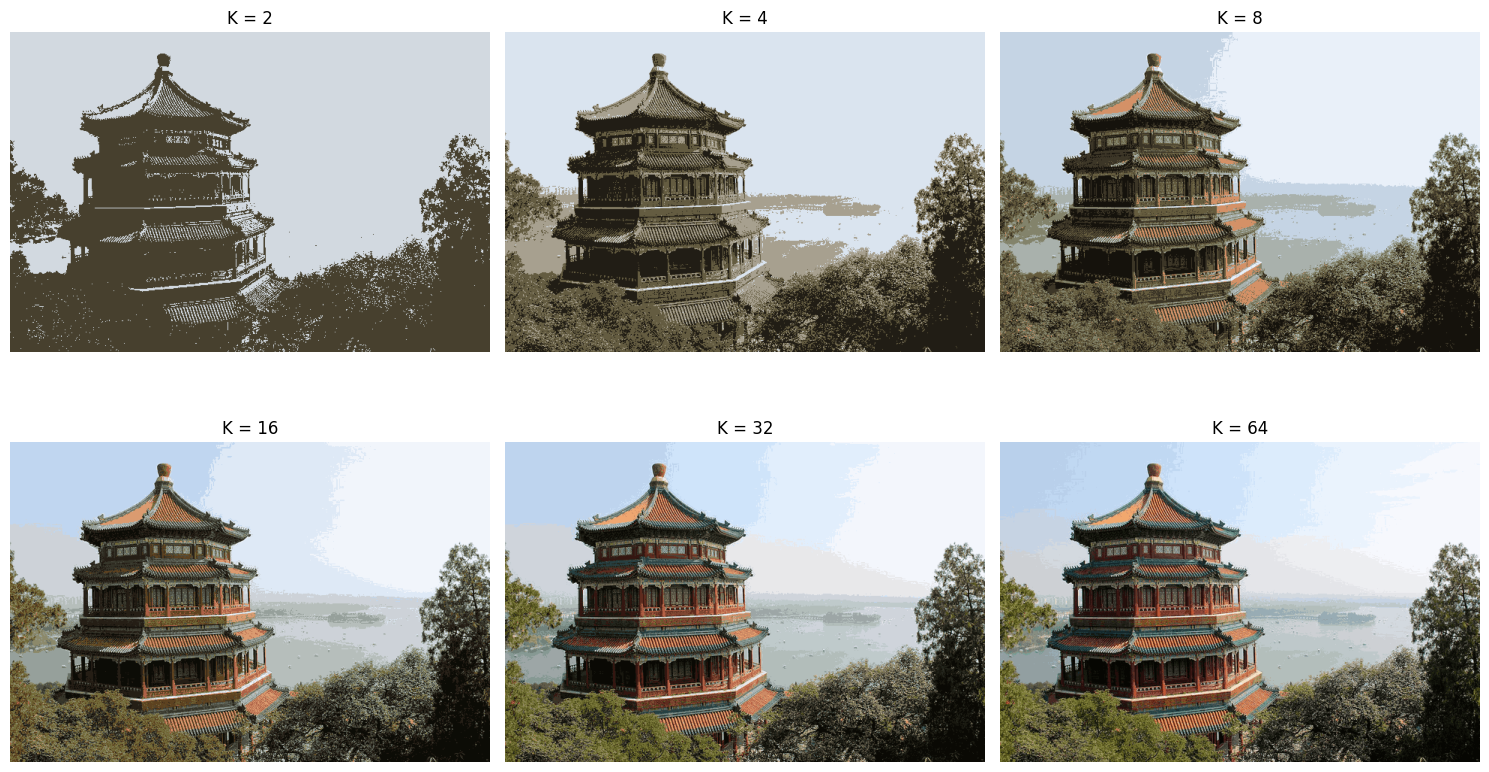

In [9]:
def compress_image(img, k, sample_size=10_000, random_state=42):
    h, w, _ = img.shape
    X = img.reshape(-1, 3) / 255.0
    idx = np.random.RandomState(random_state).choice(X.shape[0], sample_size, replace=False)
    km = KMeans(n_clusters=k, n_init=10, random_state=random_state).fit(X[idx])
    compressed = km.cluster_centers_[km.predict(X)]
    return compressed.reshape(h, w, 3)

Ks = [2, 4, 8, 16, 32, 64]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, k in zip(axes.flatten(), Ks):
    ax.imshow(compress_image(image, k))
    ax.set_title(f"K = {k}")
    ax.axis('off')

plt.tight_layout()
plt.show()

☝️ With `K=32` or `K=64` the difference with the original becomes nearly invisible, yet we store the same image with only 5 or 6 bits of color information per pixel instead of 24 bits.

## 7) Compression ratio

❓ Compute the theoretical compression ratio (ignoring the cost of storing the palette): each pixel only needs `log2(K)` bits instead of 24.

In [10]:
for k in Ks:
    bits_per_pixel = np.log2(k)
    ratio = 24 / bits_per_pixel
    print(f"K={k:>3} -> {bits_per_pixel:.0f} bits/pixel, compression ratio ≈ {ratio:.1f}x")

K=  2 -> 1 bits/pixel, compression ratio ≈ 24.0x
K=  4 -> 2 bits/pixel, compression ratio ≈ 12.0x
K=  8 -> 3 bits/pixel, compression ratio ≈ 8.0x
K= 16 -> 4 bits/pixel, compression ratio ≈ 6.0x
K= 32 -> 5 bits/pixel, compression ratio ≈ 4.8x
K= 64 -> 6 bits/pixel, compression ratio ≈ 4.0x


🏁 **Congratulations!** You just implemented a lossy image compression algorithm using an unsupervised learning technique. Don't forget to commit and push!